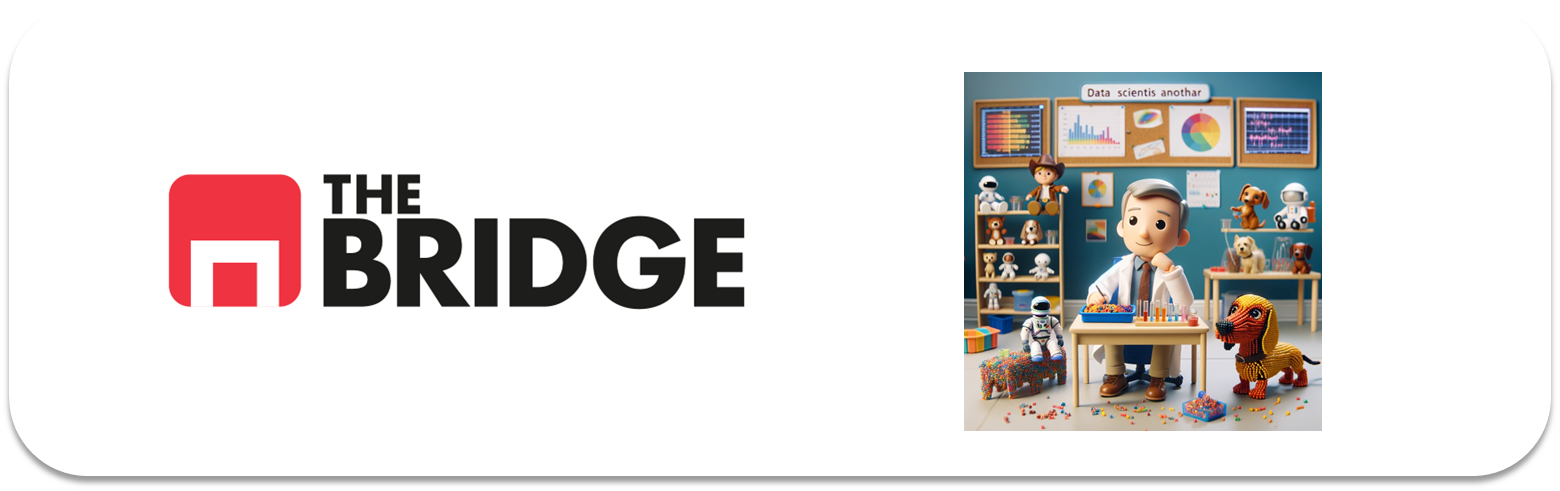

## PRACTICA OBLIGATORIA: **Análisis Univariante**

* La práctica obligatoria de esta unidad consiste en hacer el análisis univariante completo de un dataset con el que acabarás muy familiarizado, el manifiesto de pasajeros del Titanic. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook. Te dejo una que vas a necesitar sí o sí

In [1]:

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


### #1 Preparación


### #1.1


Carga en un dataframe los datos del titanic a partir de un dataset de seaborn. Para ello:

* ejecuta ```python sns.get_dataset_names()```
* localiza el nombre que puede ser el adecuado para el ejercicio
* Asigna la salida de ```sns.load_dataset(<nombre_del_dataset>)``` a una variable "df_titanic"

In [2]:
sns.get_dataset_names()

['anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'planets',
 'seaice',
 'taxis',
 'tips',
 'titanic']

In [3]:
# Carga el dataset en la variable df_titanic
df_titanic = sns.load_dataset("titanic")

### #1.2

Muestra una porción del dataset ("df_titanic") y su info general. ¿Hay nulos?

In [4]:
# Mostramos las primeras filas para verificar que se ha cargado bien
df_titanic.head(10)



,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False


In [5]:
df_titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


### #1.3

Obtén el porcentaje de nulos y decide que hacer con las columnas con nulos y ejecútalo. Además deshazte de la columna "parch" que no la emplearemos.

In [6]:
# 1. Obtener el porcentaje de nulos por columna
porcentaje_nulos = (df_titanic.isnull().sum() / len(df_titanic)) * 100
print("--- Porcentaje de nulos por columna ---")
print(porcentaje_nulos[porcentaje_nulos > 0].sort_values(ascending=False))
print("\n")

# 2. Decisiones sobre los nulos y 3. Eliminar "parch"
# DECISIÓN 'deck': Al tener ~77% de nulos, la mejor decisión es eliminar la columna completa.
# DECISIÓN 'age': Tiene ~20% de nulos. Es un porcentaje manejable, así que imputaremos los faltantes con la mediana.
# DECISIÓN 'embarked' y 'embark_town': Faltan menos del 0.3% de los datos (solo 2 filas). Podemos simplemente eliminar esas filas.
# EJECUCIÓN 'parch': La eliminamos como nos pide el enunciado

# Ejecutamos las eliminaciones de columnas ('deck' por nulos, 'parch' por enunciado)
df_titanic = df_titanic.drop(columns=['deck', 'parch'], errors='ignore')

# Ejecutamos la imputación para 'age' (rellenamos con la mediana)
df_titanic['age'] = df_titanic['age'].fillna(df_titanic['age'].median())

# Ejecutamos la eliminación de las pocas filas nulas que quedan ('embarked', 'embark_town')
df_titanic = df_titanic.dropna()

# Comprobamos que el dataset ha quedado limpio
print("--- Comprobación final de nulos ---")
print(df_titanic.isnull().sum())

--- Porcentaje de nulos por columna ---
deck           77.216611
age            19.865320
embarked        0.224467
embark_town     0.224467
dtype: float64


--- Comprobación final de nulos ---
survived       0
pclass         0
sex            0
age            0
sibsp          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64


### #1.4
Sobre el dataset "limpio". Rellena la tabla de descripción (muy breve) de lo que es cada columna en función de su nombre y los valores. Para ayudarte:
* Se trata del dataset que reune lo más parecido a un manifiesto de supervivientes y fallecidos en el viaje.
* sibsp: Es el numero de familiares que viajan con la persona indicada en el manifiesto (lista de pasajeros)
* embarked: Es la incial de la letra de la ciudad donde embarcó la persona.


| Columna/Variable | Descripción |
| :--- | :--- |
| **survived** | Indica si el pasajero sobrevivió (1) o falleció (0). |
| **pclass** | Clase del billete del pasajero (1 = 1ª, 2 = 2ª, 3 = 3ª). |
| **sex** | Sexo biológico del pasajero (male / female). |
| **age** | Edad del pasajero en años. |
| **sibsp** | Número de familiares (hermanos o cónyuge) que viajan con el pasajero. |
| **fare** | Precio o tarifa pagada por el billete. |
| **embarked** | Inicial de la ciudad donde embarcó la persona (C, Q, S). |
| **class** | Equivalente a 'pclass' pero en formato de texto (First, Second, Third). |
| **who** | Categoría demográfica del pasajero (man, woman, child). |
| **adult_male** | Variable booleana que indica si es un hombre adulto (True/False). |
| **embark_town** | Nombre completo de la ciudad de embarque (Cherbourg, Queenstown, Southampton). |
| **alive** | Equivalente a 'survived' pero en formato de texto (yes, no). |
| **alone** | Variable booleana que indica si el pasajero viajaba completamente solo (True/False). |



### #1.5

Busca en internet las tres ciudades que visitó el Titanic antes de poner rumbo a su destino y llegar a alta mar. Cambia las iniciales por esos valores.

In [7]:
# 1. Creamos un diccionario con la equivalencia de cada inicial
nombres_ciudades = {
    'S': 'Southampton',
    'C': 'Cherbourg',
    'Q': 'Queenstown'
}

# 2. Aplicamos el reemplazo a la columna 'embarked'
df_titanic['embarked'] = df_titanic['embarked'].replace(nombres_ciudades)

# 3. Comprobamos que los cambios se han aplicado correctamente
print(df_titanic['embarked'].unique())

<StringArray>
['Southampton', 'Cherbourg', 'Queenstown']
Length: 3, dtype: str


### #2 Análisis

Sabiendo que el objetivo de nuestro análisis es hacer un estudio de la superviviencia y mortalidad en el viaje... Haz un análisis univariante completo y ordenado de las siguientes variables:
["survived","who","age","fare","class","embarked","alone"]
Nota: Si quieres añadir más, perfecto.

Separa el análisis en categóricas (incluyendo binarias) y numéricas. Muestra valores, gráficas y conclusiones/observaciones (2 o 3 por variable)

### #2.1 Categóricas


ANÁLISIS DE LA VARIABLE: SURVIVED
          Cantidad  Porcentaje (%)
survived                          
0              549           61.75
1              340           38.25




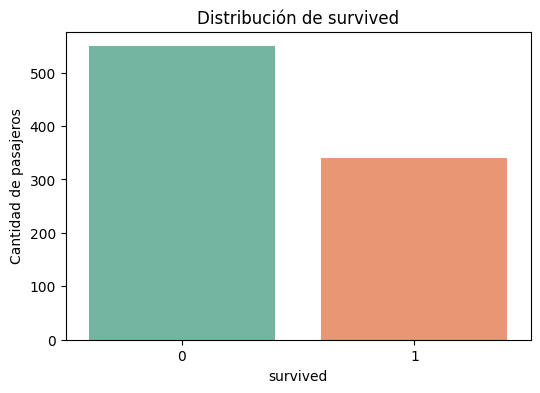


ANÁLISIS DE LA VARIABLE: WHO
       Cantidad  Porcentaje (%)
who                            
man         537           60.40
woman       269           30.26
child        83            9.34




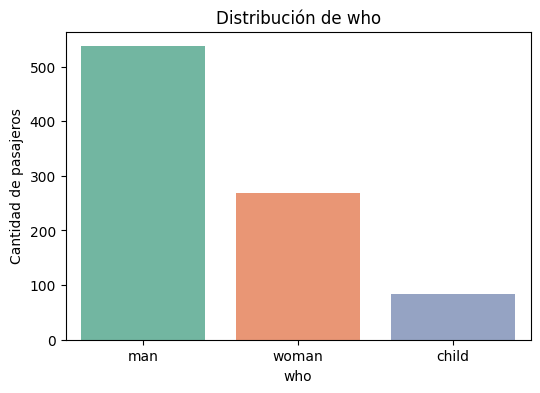


ANÁLISIS DE LA VARIABLE: CLASS
        Cantidad  Porcentaje (%)
class                           
Third        491           55.23
First        214           24.07
Second       184           20.70




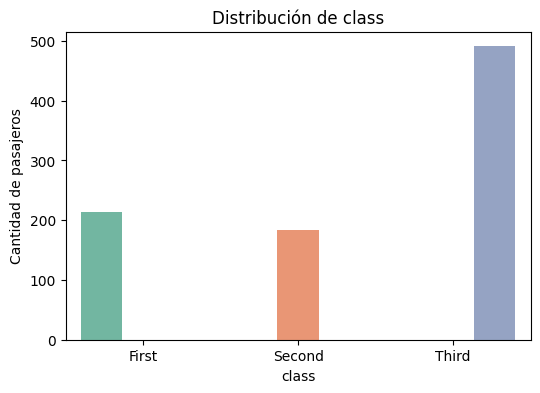


ANÁLISIS DE LA VARIABLE: EMBARKED
             Cantidad  Porcentaje (%)
embarked                             
Southampton       644           72.44
Cherbourg         168           18.90
Queenstown         77            8.66




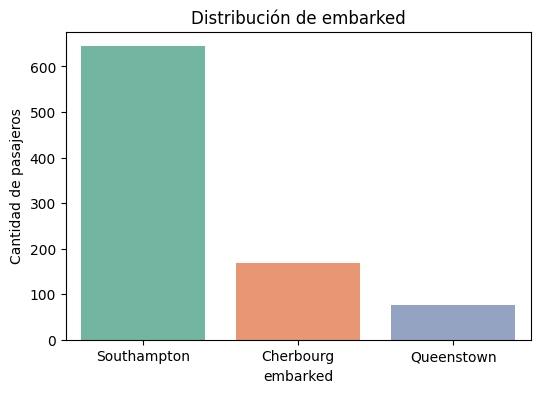


ANÁLISIS DE LA VARIABLE: ALONE
       Cantidad  Porcentaje (%)
alone                          
True        535           60.18
False       354           39.82




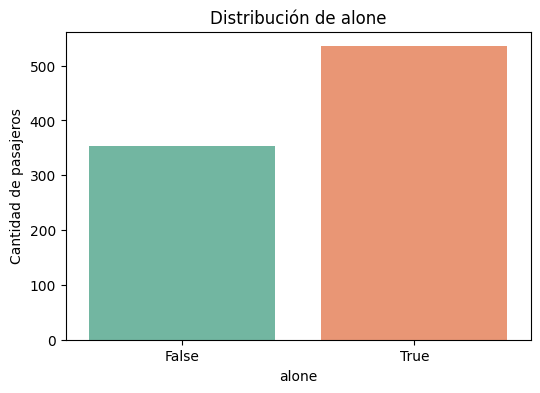

In [8]:
# Definimos la lista de variables categóricas
vars_cat = ["survived", "who", "class", "embarked", "alone"]

for col in vars_cat:
    print(f"\n" + "="*40)
    print(f"ANÁLISIS DE LA VARIABLE: {col.upper()}")
    print("="*40)
    
    # 1. Mostrar Valores (Absolutos y Porcentajes)
    valores = df_titanic[col].value_counts()
    porcentajes = df_titanic[col].value_counts(normalize=True) * 100
    df_resumen = pd.DataFrame({'Cantidad': valores, 'Porcentaje (%)': porcentajes.round(2)})
    print(df_resumen)
    print("\n")
    
    # 2. Gráfica
    plt.figure(figsize=(6, 4))
    # Usamos countplot para contar frecuencias en variables categóricas
    sns.countplot(data=df_titanic, x=col, hue=col, palette='Set2', legend=False)
    plt.title(f'Distribución de {col}')
    plt.ylabel('Cantidad de pasajeros')
    plt.xlabel(col)
    
    # Mostrar la gráfica
    plt.show()

### Conclusiones del Análisis Univariante (Categóricas)

**1. Variable `survived` (Variable Objetivo)**
* **Desbalanceo:** La mayoría de los pasajeros no sobrevivieron (aprox. 61.6%).
* **Contexto:** Al ser nuestra variable objetivo, esta proporción nos indica la "tasa base" de supervivencia del evento y señala que nuestro dataset está ligeramente desbalanceado hacia la clase mayoritaria (0 = fallecidos).

**2. Variable `who` (Demografía general)**
* **Predominancia masculina:** La gran mayoría del pasaje estaba compuesto por hombres adultos (más del 60%).
* **Minoría infantil:** Los niños representan la proporción más pequeña a bordo (en torno a un 9%).

**3. Variable `class` (Clase del billete)**
* **Distribución piramidal invertida:** Más de la mitad de los pasajeros (aprox. 55%) viajaban en Tercera Clase (Third).
* **Anomalía económica:** Curiosamente, viajaban más personas en Primera Clase que en Segunda Clase, lo que nos habla de una clara polarización en el poder adquisitivo del pasaje.

**4. Variable `embarked` (Puerto de origen)**
* **Puerto principal:** Southampton (S) fue, con muchísima diferencia, el puerto donde embarcó el grueso de los pasajeros (más del 72%).
* **Resto de puertos:** Queenstown (Q) fue el puerto con menor afluencia, aportando menos del 10% del pasaje.

**5. Variable `alone` (Compañía en el viaje)**
* **Viajeros solitarios:** Alrededor del 60% de los pasajeros viajaban completamente solos (True).
* **Correlación demográfica:** Este dato tiene mucho sentido si lo cruzamos mentalmente con la variable `who`, ya que la alta cantidad de hombres adultos solía corresponder a trabajadores o emigrantes que viajaban solos buscando oportunidades.

### #2.2 Numéricas


ANÁLISIS DE LA VARIABLE: AGE
count    889.00
mean      29.32
std       12.98
min        0.42
25%       22.00
50%       28.00
75%       35.00
max       80.00
Name: age, dtype: float64




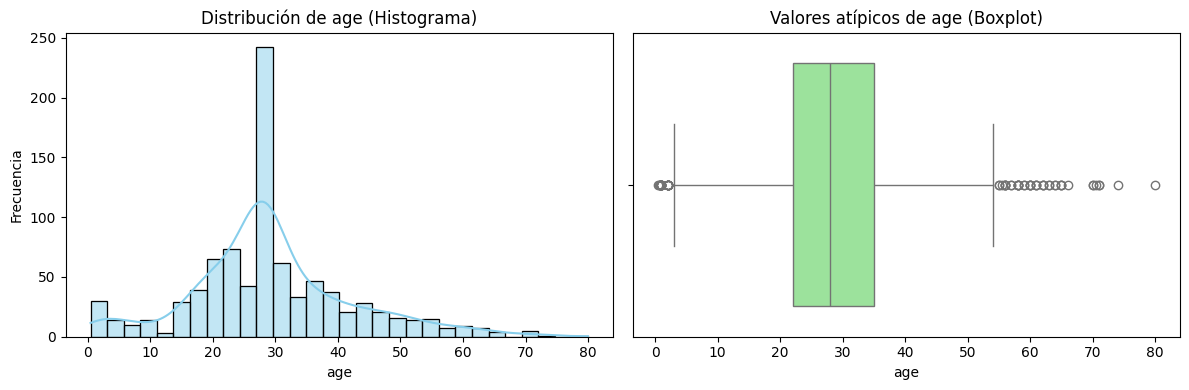


ANÁLISIS DE LA VARIABLE: FARE
count    889.00
mean      32.10
std       49.70
min        0.00
25%        7.90
50%       14.45
75%       31.00
max      512.33
Name: fare, dtype: float64




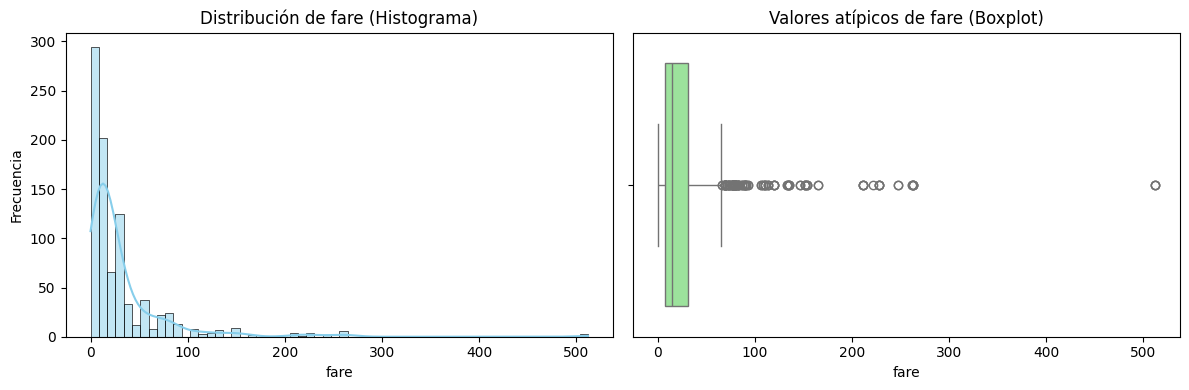

In [9]:
# Definimos la lista de variables numéricas
vars_num = ["age", "fare"]

for col in vars_num:
    print(f"\n" + "="*50)
    print(f"ANÁLISIS DE LA VARIABLE: {col.upper()}")
    print("="*50)
    
    # 1. Mostrar Estadísticas Descriptivas (media, min, max, cuartiles...)
    print(df_titanic[col].describe().round(2))
    print("\n")
    
    # 2. Gráficas: Creamos un "lienzo" con 1 fila y 2 columnas para poner 2 gráficos juntos
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Gráfico 1: Histograma (con curva de densidad o KDE)
    sns.histplot(data=df_titanic, x=col, kde=True, ax=axes[0], color='skyblue')
    axes[0].set_title(f'Distribución de {col} (Histograma)')
    axes[0].set_ylabel('Frecuencia')
    
    # Gráfico 2: Boxplot (Diagrama de caja y bigotes)
    sns.boxplot(data=df_titanic, x=col, ax=axes[1], color='lightgreen')
    axes[1].set_title(f'Valores atípicos de {col} (Boxplot)')
    
    # Ajustar el diseño y mostrar
    plt.tight_layout()
    plt.show()

### Conclusiones del Análisis Univariante (Numéricas)

**1. Variable `age` (Edad)**
* **Impacto de la limpieza de datos:** En el histograma se observa un pico enorme y antinatural alrededor de los 28 años. Esto no es casualidad; es el resultado directo de nuestra decisión anterior de imputar el ~20% de los valores nulos usando la mediana.
* **Juventud a bordo:** Descontando ese pico artificial, la distribución nos muestra que la mayoría del pasaje era bastante joven, concentrándose el grueso entre los 20 y los 38 años.
* **Valores atípicos (Outliers):** El boxplot muestra puntos más allá del "bigote" superior. Nos indica que había unos pocos pasajeros de edad muy avanzada para la época (entre 65 y 80 años).

**2. Variable `fare` (Tarifa del billete)**
* **Fuerte asimetría positiva (Sesgo a la derecha):** La inmensa mayoría de los pasajeros pagó tarifas muy bajas (menos de 35 libras). Esto cuadra perfectamente con lo que vimos en las variables categóricas: la mayoría viajaba en Tercera Clase.
* **Outliers extremos:** El diagrama de caja está completamente aplastado hacia la izquierda debido a unos pocos valores atípicos absurdamente altos. Hay unos pocos billetes que costaron más de 200 y hasta 500 libras (probablemente las mejores suites de Primera Clase).
* **Posible transformación:** Dado el enorme sesgo de esta variable, si fuéramos a entrenar un modelo de Machine Learning, seguramente necesitaríamos aplicar un logaritmo a `fare` para suavizar la curva.